In [1]:
# ! pip install pypower --quiet

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import os

SEED = 2024
torch.manual_seed(SEED)

# The solution of the AC-OPF provides a setpoint for power generations in order to satisfy a specific state of electricity consumtion !!!!!!!


In [3]:
# Load the network for Case5
net = {
    "baseMVA": 100.0,
## area data
    "areas": np.array([[1, 4]]),
## bus data
###	bus_i	type	Pd	Qd	Gs	Bs	area	Vm	Va	baseKV	zone	Vmax	Vmin
    "bus": np.array([
            [1, 2, 0.0, 0.0, 0.0, 0.0, 1, 1.00000, 0.00000, 230.0, 1, 1.10000, 0.90000],
            [2, 1, 300.0, 98.61, 0.0, 0.0, 1, 1.00000, 0.00000, 230.0, 1, 1.10000, 0.90000],
            [3, 2, 300.0, 98.61, 0.0, 0.0, 1, 1.00000, 0.00000, 230.0, 1, 1.10000, 0.90000],
            [4, 3, 400.0, 131.47, 0.0, 0.0, 1, 1.00000, 0.00000, 230.0, 1, 1.10000, 0.90000],
            [5, 2, 0.0, 0.0, 0.0, 0.0, 1, 1.00000, 0.00000, 230.0, 1, 1.10000, 0.90000]
        ]),
## generator data
###	bus	Pg	Qg	Qmax	Qmin	Vg	mBase	status	Pmax	Pmin
    "gen": np.array([
            [1, 20.0, 0.0, 30.0, -30.0, 1.0, 100.0, 1, 40.0, 0.0],
            [1, 85.0, 0.0, 127.5, -127.5, 1.0, 100.0, 1, 170.0, 0.0],
            [3, 260.0, 0.0, 390.0, -390.0, 1.0, 100.0, 1, 520.0, 0.0],
            [4, 100.0, 0.0, 150.0, -150.0, 1.0, 100.0, 1, 200.0, 0.0],
            [5, 300.0, 0.0, 450.0, -450.0, 1.0, 100.0, 1, 600.0, 0.0]
        ]),
## generator cost data
###	2	startup	shutdown	n	c(n-1)	...	c0
    "gencost": np.array([
            [2, 0.0, 0.0, 3, 0.000000, 14.000000, 0.000000],
            [2, 0.0, 0.0, 3, 0.000000, 15.000000, 0.000000],
            [2, 0.0, 0.0, 3, 0.000000, 30.000000, 0.000000],
            [2, 0.0, 0.0, 3, 0.000000, 40.000000, 0.000000],
            [2, 0.0, 0.0, 3, 0.000000, 10.000000, 0.000000]
        ]),
## branch data
###	fbus	tbus	r	x	b	rateA	rateB	rateC	ratio	angle	status	angmin	angmax
    "branch": np.array([
            [1, 2, 0.00281, 0.0281, 0.00712, 400.0, 400.0, 400.0, 0.0, 0.0, 1, -30.0, 30.0],
            [1, 4, 0.00304, 0.0304, 0.00658, 426, 426, 426, 0.0, 0.0, 1, -30.0, 30.0],
            [1, 5, 0.00064, 0.0064, 0.03126, 426, 426, 426, 0.0, 0.0, 1, -30.0, 30.0],
            [2, 3, 0.00108, 0.0108, 0.01852, 426, 426, 426, 0.0, 0.0, 1, -30.0, 30.0],
            [3, 4, 0.00297, 0.0297, 0.00674, 426, 426, 426, 0.0, 0.0, 1, -30.0, 30.0],
            [4, 5, 0.00297, 0.0297, 0.00674, 240.0, 240.0, 240.0, 0.0, 0.0, 1, -30.0, 30.0]
        ])
}


In [4]:
bus = pd.DataFrame(net['bus'],
                   columns=['bus_i', 'type',	'Pd',	'Qd',	'Gs',	'Bs',
                            'area',	'Vm',	'Va',	'baseKV',	'zone',	'Vmax',	'Vmin'])
print(f"n_bus:{len(bus)}")
bus

n_bus:5


,bus_i,type,Pd,Qd,Gs,Bs,area,Vm,Va,baseKV,zone,Vmax,Vmin
0,1.0,2.0,0.0,0.00,0.0,0.0,1.0,1.0,0.0,230.0,1.0,1.1,0.9
1,2.0,1.0,300.0,98.61,0.0,0.0,1.0,1.0,0.0,230.0,1.0,1.1,0.9
2,3.0,2.0,300.0,98.61,0.0,0.0,1.0,1.0,0.0,230.0,1.0,1.1,0.9
3,4.0,3.0,400.0,131.47,0.0,0.0,1.0,1.0,0.0,230.0,1.0,1.1,0.9
4,5.0,2.0,0.0,0.00,0.0,0.0,1.0,1.0,0.0,230.0,1.0,1.1,0.9


In [5]:
gen = pd.DataFrame(net['gen'],
                   columns = ['bus',	'Pg',	'Qg',
                              'Qmax',	'Qmin',	'Vg',
                              'mBase',	'status',	'Pmax',	'Pmin'])
gen

,bus,Pg,Qg,Qmax,Qmin,Vg,mBase,status,Pmax,Pmin
0,1.0,20.0,0.0,30.0,-30.0,1.0,100.0,1.0,40.0,0.0
1,1.0,85.0,0.0,127.5,-127.5,1.0,100.0,1.0,170.0,0.0
2,3.0,260.0,0.0,390.0,-390.0,1.0,100.0,1.0,520.0,0.0
3,4.0,100.0,0.0,150.0,-150.0,1.0,100.0,1.0,200.0,0.0
4,5.0,300.0,0.0,450.0,-450.0,1.0,100.0,1.0,600.0,0.0


In [6]:
# The bus variables indicate where the generator is connected on the grid !!!!!!

In [7]:
line = pd.DataFrame(net['branch'],
                    columns = ['fbus',	'tbus',	'r',	'x',	'b',
                               'rateA',	'rateB',	'rateC',	'ratio',
                               'angle',	'status',	'angmin',	'angmax'] )
line

,fbus,tbus,r,x,b,rateA,rateB,rateC,ratio,angle,status,angmin,angmax
0,1.0,2.0,0.00281,0.0281,0.00712,400.0,400.0,400.0,0.0,0.0,1.0,-30.0,30.0
1,1.0,4.0,0.00304,0.0304,0.00658,426.0,426.0,426.0,0.0,0.0,1.0,-30.0,30.0
2,1.0,5.0,0.00064,0.0064,0.03126,426.0,426.0,426.0,0.0,0.0,1.0,-30.0,30.0
3,2.0,3.0,0.00108,0.0108,0.01852,426.0,426.0,426.0,0.0,0.0,1.0,-30.0,30.0
4,3.0,4.0,0.00297,0.0297,0.00674,426.0,426.0,426.0,0.0,0.0,1.0,-30.0,30.0
5,4.0,5.0,0.00297,0.0297,0.00674,240.0,240.0,240.0,0.0,0.0,1.0,-30.0,30.0


In [8]:
# lines connecting from_bus to to_bus with some specific parameters, e.g. resistance (r) and reactance (x).

In [9]:
gen_cost = pd.DataFrame(net['gencost'],
                        columns = ['order_poly', 'startup', 'shutdown', 'num_coefficient', 'c2', 'c1', 'c0'])
gen_cost

,order_poly,startup,shutdown,num_coefficient,c2,c1,c0
0,2.0,0.0,0.0,3.0,0.0,14.0,0.0
1,2.0,0.0,0.0,3.0,0.0,15.0,0.0
2,2.0,0.0,0.0,3.0,0.0,30.0,0.0
3,2.0,0.0,0.0,3.0,0.0,40.0,0.0
4,2.0,0.0,0.0,3.0,0.0,10.0,0.0


In [10]:
# First, we use PyPower to solve the complex AC-OPF problem

In [11]:
#! pip install pyrlu


In [12]:
from pypower.api import runopf, ppoption

In [13]:
# Run power flow to get results
option = ppoption(OUT_ALL=-1) # set the output details

In [14]:
result = runopf(net, option) # run the ACOPF

PYPOWER Version 5.1.17, 02-Sept-2024 -- AC Optimal Power Flow
Python Interior Point Solver - PIPS, Version 1.0, 07-Feb-2011
Numerically failed.
Did not converge in 2 iterations.

Did not converge (0.08 seconds)

Objective Function Value = 13007.90 $/hr
|     System Summary                                                           |

How many?                How much?              P (MW)            Q (MVAr)
---------------------    -------------------  -------------  -----------------
Buses              5     Total Gen Capacity    1530.0       -1147.5 to 1147.5
Generators         5     On-line Capacity      1530.0       -1147.5 to 1147.5
Committed Gens     5     Generation (actual)    498.7              79.1
Loads              3     Load                  1000.0             328.7
  Fixed            3       Fixed               1000.0             328.7
  Dispatchable     0       Dispatchable           0.0 of 0.0        0.0
Shunts             0     Shunt (inj)              0.0              

# Machine learning for AC-OPF

In [15]:
"""================================Training Data Generation================================"""

'================================Training Data Generation================================'

In [16]:
from pypower import idx_bus, idx_gen, idx_brch
from tqdm import tqdm

In [17]:
nbus = len(net['bus'])
ngen = len(net['gen'])
basemva = net['baseMVA']
PD_base = net['bus'][:, idx_bus.PD]
QD_base = net['bus'][:, idx_bus.QD]

In [18]:
data_size = 10

In [19]:
# randomly sample load demand from its default value
PD_data = PD_base * np.random.uniform(0.9, 1.1, [data_size, 1])
QD_data = QD_base * np.random.uniform(0.9, 1.1, [data_size, 1])

PG_data = np.zeros([data_size, ngen])
QG_data = np.zeros([data_size, ngen])

VM_data = np.zeros([data_size, ngen])
VA_data = np.zeros([data_size, ngen])


In [20]:
VM_data

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [21]:
QD_data.shape

(10, 5)

In [22]:
PD_base.shape

(5,)

In [23]:
# then for each load demand, we run the solver to obtain the optimal solution
for i in tqdm(range(data_size)):
    net['bus'][:, idx_bus.PD] = PD_data[i]
    net['bus'][:, idx_bus.QD] = QD_data[i]
    option = ppoption(VERBOSE=0, OUT_ALL=0)
    result = runopf(net, option)
    PG_data[i] = result['gen'][:, idx_gen.PG]
    QG_data[i] = result['gen'][:, idx_gen.QG]
    VM_data[i] = result['gen'][:, idx_bus.VM]
    VA_data[i] = result['gen'][:, idx_bus.VA]

100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 12.44it/s]


# Import Prepared Training Data

In [24]:
""" OPF-Learn: An Open-Source Framework for Creating Representative AC Optimal Power Flow Datasets" and in the package website: OPFLearn.jl and OPFLearnData."""

' OPF-Learn: An Open-Source Framework for Creating Representative AC Optimal Power Flow Datasets" and in the package website: OPFLearn.jl and OPFLearnData.'

In [4]:
# ! mkdir data
# ! wget https://data.nrel.gov/system/files/177/pglib_opf_case5_pjm.csv -P data/

mkdir: cannot create directory ‘data’: File exists
--2025-01-24 17:30:20--  https://data.nrel.gov/system/files/177/pglib_opf_case60_ieee.csv
Resolving data.nrel.gov (data.nrel.gov)... 76.223.107.85, 13.248.240.147
Connecting to data.nrel.gov (data.nrel.gov)|76.223.107.85|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-01-24 17:30:21 ERROR 404: Not Found.



# Data exploration

In [26]:
df = pd.read_csv('./data/pglib_opf_case5_pjm.csv')
df.head()

,load1:pl,load2:pl,load3:pl,load1:ql,load2:ql,load3:ql,gen1:pg,gen2:pg,gen3:pg,gen4:pg,...,line3:p_fr_max,line4:p_fr_max,line5:p_fr_max,line6:p_fr_max,line1:q_fr_max,line2:q_fr_max,line3:q_fr_max,line4:q_fr_max,line5:q_fr_max,line6:q_fr_max
0,6.570765,2.275993,4.051883,4.376283,0.628149,4.026378,0.4,1.7,4.876424,1.558644,...,-0.000002,-0.000003,-2.720498e-07,-0.000006,0.000000e+00,0.0,-7.933284e-07,-1.873404e-06,0.0,-3.069352e-06
1,6.552550,1.704638,4.090173,4.400894,0.724693,3.937011,0.4,1.7,4.317437,1.531758,...,-0.000002,-0.000003,-2.624331e-07,-0.000006,0.000000e+00,0.0,-7.848656e-07,-1.892890e-06,0.0,-2.936123e-06
2,5.645406,2.029723,5.955067,1.377338,0.865517,3.240306,0.4,1.7,5.199999,1.490930,...,-0.000002,-0.000002,0.000000e+00,-0.000280,-1.365476e-07,0.0,0.000000e+00,-8.479213e-07,0.0,-3.177477e-07
3,4.778645,2.417017,6.361179,0.843277,0.881531,2.635903,0.4,1.7,5.200000,1.644658,...,-0.000001,-0.000001,0.000000e+00,-0.647117,-3.141235e-07,0.0,0.000000e+00,-7.238938e-07,0.0,-6.550166e-09
4,5.690040,2.458801,5.745494,2.003454,1.119158,3.286294,0.4,1.7,5.200000,1.684051,...,-0.000002,-0.000002,-5.028490e-09,-0.000067,0.000000e+00,0.0,0.000000e+00,-9.201327e-07,0.0,-6.686726e-07


In [27]:
df.shape

(10000, 104)

In [28]:
df.columns

Index(['load1:pl', 'load2:pl', 'load3:pl', 'load1:ql', 'load2:ql', 'load3:ql',
       'gen1:pg', 'gen2:pg', 'gen3:pg', 'gen4:pg',
       ...
       'line3:p_fr_max', 'line4:p_fr_max', 'line5:p_fr_max', 'line6:p_fr_max',
       'line1:q_fr_max', 'line2:q_fr_max', 'line3:q_fr_max', 'line4:q_fr_max',
       'line5:q_fr_max', 'line6:q_fr_max'],
      dtype='object', length=104)

In [29]:
""" We can see that this is dataset of 10000 rows by 104 columns.
    Each row represents the feature and solution of the AC-OPF.
    Let's define the inputs and outputs for the machine learning based on the AC-OPF formulation we have learned.
"""

" We can see that this is dataset of 10000 rows by 104 columns.\n    Each row represents the feature and solution of the AC-OPF.\n    Let's define the inputs and outputs for the machine learning based on the AC-OPF formulation we have learned.\n"

In [30]:
""" For example, columns 0:3 represents the active power consumption for the loads, while comlumns 3:6 represent the reactive power consumption of the loads.
    We can now separete them into a variable called "input", which means they are the input parameters for the AC-OPF problem.
"""

' For example, columns 0:3 represents the active power consumption for the loads, while comlumns 3:6 represent the reactive power consumption of the loads.\n    We can now separete them into a variable called "input", which means they are the input parameters for the AC-OPF problem.\n'

In [31]:
# define input columns

load_p = list(df.columns[0:3])
load_q = list(df.columns[3:6])
inputs = load_p + load_q
print(inputs)

['load1:pl', 'load2:pl', 'load3:pl', 'load1:ql', 'load2:ql', 'load3:ql']


In [32]:
""" We can do the same with the outputs, the optimal solution for the AC-OPF problem given load demand,
    which includes the active and reactive power at each generator as well as the voltage magnitude and angle at each bus.
"""

' We can do the same with the outputs, the optimal solution for the AC-OPF problem given load demand,\n    which includes the active and reactive power at each generator as well as the voltage magnitude and angle at each bus.\n'

In [33]:
# Define output columns

gen_p = list(df.columns[6:11])
gen_q = list(df.columns[11:16])

In [34]:
gen_p

['gen1:pg', 'gen2:pg', 'gen3:pg', 'gen4:pg', 'gen5:pg']

In [35]:
def convert(x):
    #Remove spaces around the '+' or '-' before 'j'
    x = x.replace(" + ", "+").replace(" - ", "-").replace(" j ", "j").strip()
    return np.complex64(x)

In [36]:
df.columns[21:26]

Index(['bus1:v_bus', 'bus2:v_bus', 'bus3:v_bus', 'bus4:v_bus', 'bus5:v_bus'], dtype='object')

In [37]:
bus_vm = []
bus_va = []
for bus_v_column in df.columns[21:26]:
    df[bus_v_column + '_mag'] = df[bus_v_column].apply(convert).apply(np.abs)
    bus_vm.append(bus_v_column + '_mag')
    
    df[bus_v_column + '_ang'] = df[bus_v_column].apply(convert).apply(np.angle)
    ## the follow line of code is to correct a bug in the OPFLearn dataset
    df[bus_v_column + '_ang'] = -1*np.rad2deg(df[bus_v_column + '_ang'].values)
    bus_va.append(bus_v_column + '_ang')
    
outputs = gen_p + gen_q + bus_vm + bus_va
print(outputs)
    

['gen1:pg', 'gen2:pg', 'gen3:pg', 'gen4:pg', 'gen5:pg', 'gen1:qg', 'gen2:qg', 'gen3:qg', 'gen4:qg', 'gen5:qg', 'bus1:v_bus_mag', 'bus2:v_bus_mag', 'bus3:v_bus_mag', 'bus4:v_bus_mag', 'bus5:v_bus_mag', 'bus1:v_bus_ang', 'bus2:v_bus_ang', 'bus3:v_bus_ang', 'bus4:v_bus_ang', 'bus5:v_bus_ang']


In [38]:
df

,load1:pl,load2:pl,load3:pl,load1:ql,load2:ql,load3:ql,gen1:pg,gen2:pg,gen3:pg,gen4:pg,...,bus1:v_bus_mag,bus1:v_bus_ang,bus2:v_bus_mag,bus2:v_bus_ang,bus3:v_bus_mag,bus3:v_bus_ang,bus4:v_bus_mag,bus4:v_bus_ang,bus5:v_bus_mag,bus5:v_bus_ang
0,6.570765,2.275993,4.051883,4.376283,0.628149,4.026378,0.4,1.7,4.876424,1.558644e+00,...,1.088747,0.031466,1.027343,-0.047701,1.058290,-0.018030,1.055571,-1.044813e-31,1.100000,0.044278
1,6.552550,1.704638,4.090173,4.400894,0.724693,3.937011,0.4,1.7,4.317437,1.531758e+00,...,1.088817,0.032032,1.027087,-0.046907,1.058152,-0.017335,1.056337,-7.842915e-32,1.100000,0.044911
2,5.645406,2.029723,5.955067,1.377338,0.865517,3.240306,0.4,1.7,5.199999,1.490930e+00,...,1.081929,0.046786,1.080142,-0.020623,1.100000,0.003993,1.064614,-4.099984e-33,1.076183,0.061261
3,4.778645,2.417017,6.361179,0.843277,0.881531,2.635903,0.4,1.7,5.200000,1.644658e+00,...,1.073330,0.049556,1.082470,-0.011662,1.100000,0.007987,1.059389,3.173137e-36,1.064221,0.063242
4,5.690040,2.458801,5.745494,2.003454,1.119158,3.286294,0.4,1.7,5.200000,1.684051e+00,...,1.095219,0.043703,1.079232,-0.025925,1.100000,-0.002590,1.075028,2.562954e-33,1.093446,0.058019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,4.254369,4.712440,4.836094,2.668600,3.629953,1.640128,0.4,1.7,5.200000,1.622811e+00,...,1.093770,0.042283,1.039607,-0.028559,1.051908,-0.017452,1.076681,-8.360963e-35,1.100000,0.055911
9996,3.210700,1.671734,4.661965,1.612852,0.490558,2.501960,0.4,1.7,3.086005,1.944606e-07,...,1.075134,0.050848,1.078772,-0.002335,1.100000,0.005464,1.062197,3.296830e-36,1.066963,0.062918
9997,4.979303,3.477785,4.071830,2.229018,3.314802,2.390931,0.4,1.7,5.200000,5.078266e-01,...,1.094907,0.041556,1.049922,-0.026832,1.061713,-0.007820,1.073106,4.240605e-34,1.100000,0.054636
9998,2.047435,5.546288,4.167393,0.539519,4.802855,0.740298,0.4,1.7,5.200000,7.091980e-02,...,1.100000,0.048322,1.074188,-0.002144,1.072140,-0.003328,1.092085,2.087602e-34,1.097649,0.059401


In [39]:
""" Take a look into each of those columns.
    The following function plots the histogram of each variable, so it takes the whole 10000 samples for each variable and plots the distribution.
    On the x-axis we see the variable value and on the y-axis the frequency of samples that fit into a specific bucket or bin.
    We will be using 10 bins just to get an idea of the shape of the distribution.
    Notice that we are also annotating the mean of all the samples in black.
"""

' Take a look into each of those columns.\n    The following function plots the histogram of each variable, so it takes the whole 10000 samples for each variable and plots the distribution.\n    On the x-axis we see the variable value and on the y-axis the frequency of samples that fit into a specific bucket or bin.\n    We will be using 10 bins just to get an idea of the shape of the distribution.\n    Notice that we are also annotating the mean of all the samples in black.\n'

In [40]:
def plot_hist_variable(variable):
    fig, axs = plt.subplots(nrows=1, ncols=len(variable), figsize=(16,3))
    for i, input_name in enumerate(variable):
        axs[i].hist(df[input_name], bins=10, density=True)
        axs[i].set_title(input_name, fontsize=18)
        mean_value = df[input_name].mean()
        axs[i].axvline(mean_value, color='k', linestyle='dashed', linewidth=2)
        x_offset = axs[i].get_xlim()[1] * 0.02
        y_offset = axs[i].get_ylim()[1] * 0.05
        axs[i].annotate(f"Mean: {mean_value: .2f}", xy=(mean_value, axs[i].get_ylim()[1]),
                       xytext=(mean_value+x_offset, axs[i].get_ylim()[1]-y_offset),
                       ha='left', va='top', fontsize=12,
                       bbox=dict(facecolor='white', edgecolor='black', boxstyle='round'))
        if 'pl' in input_name: axs[i].set_xlabel('active load (p.u)', fontsize=14)
        elif 'ql' in input_name: axs[i].set_xlabel('reactive load (p.u)', fontsize=14)
        elif 'pg' in input_name: axs[i].set_xlabel('active gen (p.u)', fontsize=14)
        elif 'qg' in input_name: axs[i].set_xlabel('reactive gen (p.u)', fontsize=14)
        elif 'mag' in input_name: axs[i].set_xlabel('bus vol. mag. (p.u)', fontsize=14)
        elif 'ang' in input_name: axs[i].set_xlabel('bus vol. ang. (rad)', fontsize=14)
    fig.tight_layout()
    plt.show()

# Input

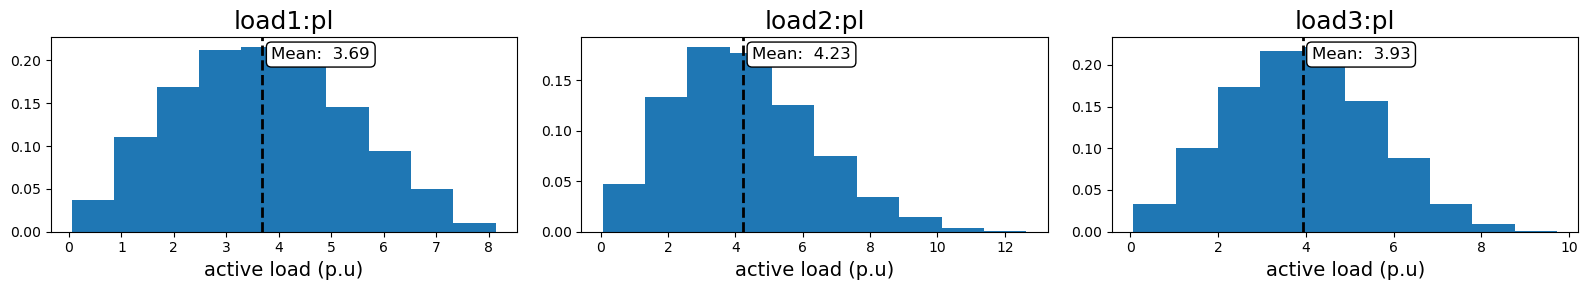

In [41]:
plot_hist_variable(load_p)

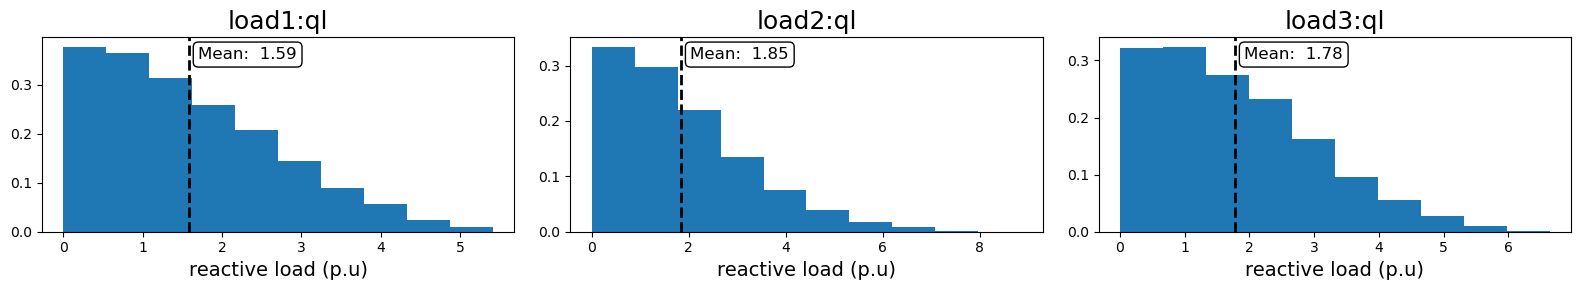

In [42]:
plot_hist_variable(load_q)

In [43]:
""" Both active and reactive power variables are positive.
    This make sense as we can not consumer "negative" power by definition.
    This really depends on the choice of methematical convention in this case, you will see that generators can "generate negative" reactive power.
    The shape of the distributions of both variables are a bit different, where active power can be generalized as a Normal distribution, while the reactive power looks like an Exponential or Log(Normal) distribution
"""

' Both active and reactive power variables are positive.\n    This make sense as we can not consumer "negative" power by definition.\n    This really depends on the choice of methematical convention in this case, you will see that generators can "generate negative" reactive power.\n    The shape of the distributions of both variables are a bit different, where active power can be generalized as a Normal distribution, while the reactive power looks like an Exponential or Log(Normal) distribution\n'

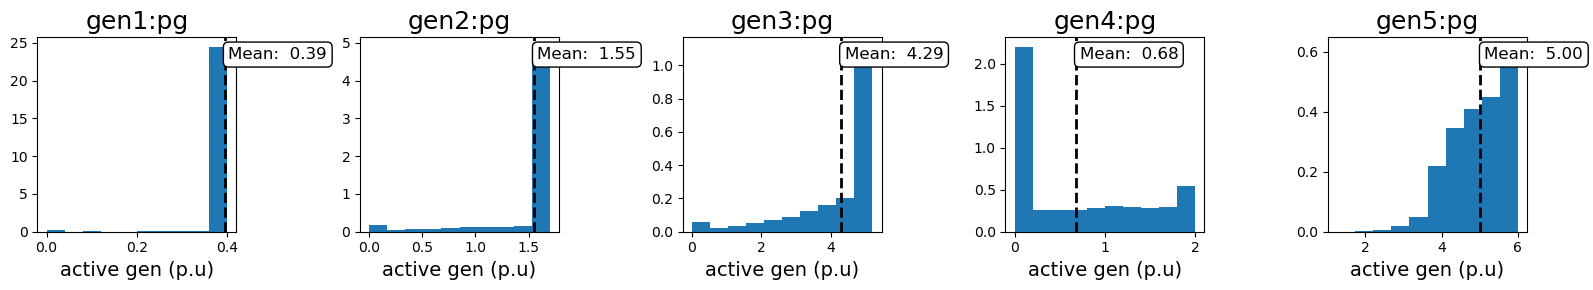

In [44]:
plot_hist_variable(gen_p)

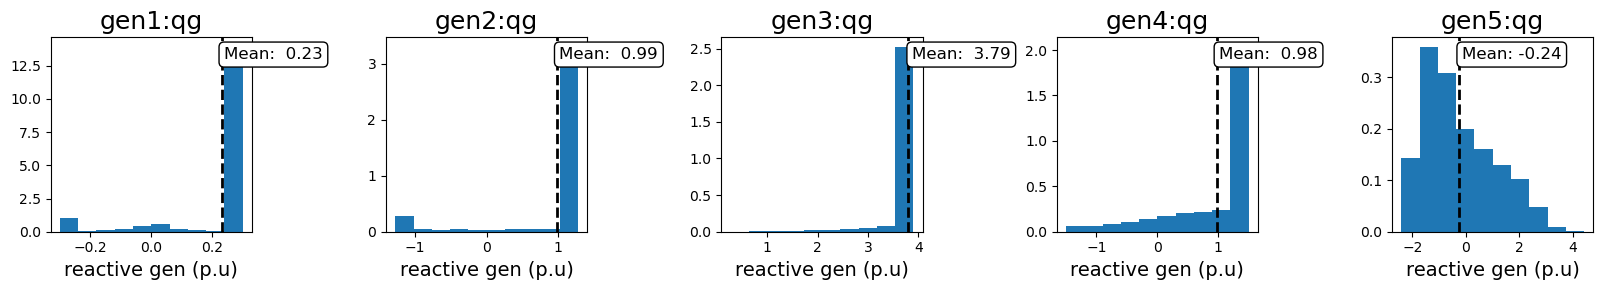

In [45]:
plot_hist_variable(gen_q)

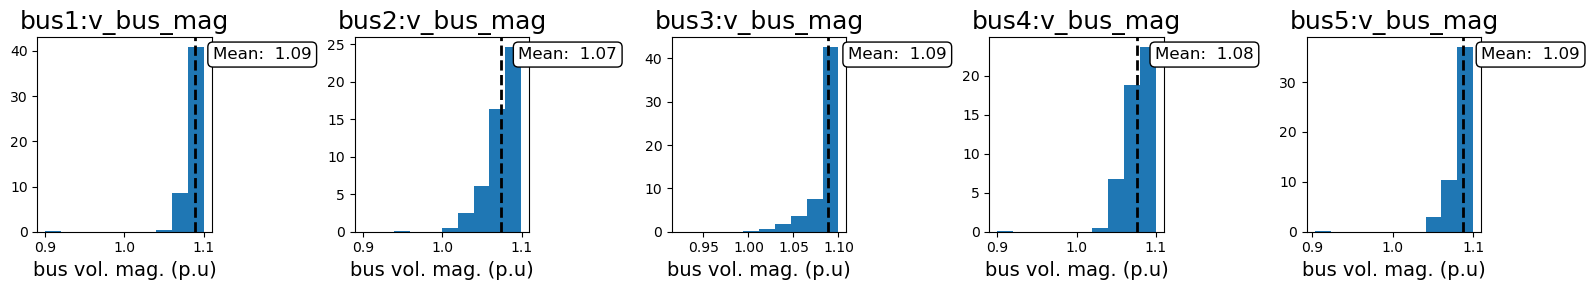

In [46]:
plot_hist_variable(bus_vm)

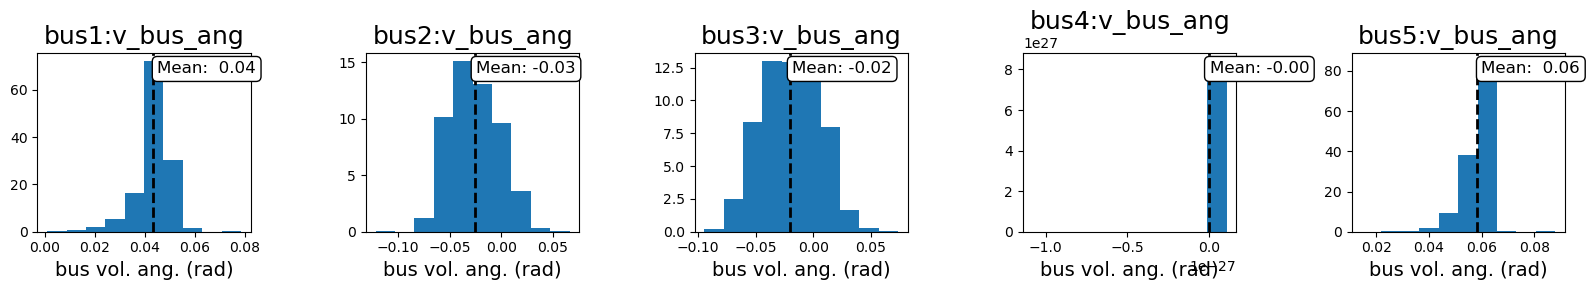

In [47]:
plot_hist_variable(bus_va)

In [48]:
""" We can see that generators'setpoints are set always at the same level most of the time.
    Notice that some generators are generating "negative" reactive power.
    This mean, by convention, that sometimes these generators are consuming reactive power instead of generating.
    In the case of voltage magnitude, it is very constant around the mean with a few samples below that level.
    This is expected as the voltage magnitude values are constrained by the AC-OPF problem.
"""

' We can see that generators\'setpoints are set always at the same level most of the time.\n    Notice that some generators are generating "negative" reactive power.\n    This mean, by convention, that sometimes these generators are consuming reactive power instead of generating.\n    In the case of voltage magnitude, it is very constant around the mean with a few samples below that level.\n    This is expected as the voltage magnitude values are constrained by the AC-OPF problem.\n'

# Case Study: Traditional Machine learning for Solving AC-OPF

In [49]:
torch.cuda.is_available()
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"=======Using {device} device==========")

=======Using cuda device==========


In [50]:
class NeuralNetwork(nn.Module):
    def __init__(self, x_size=3, y_size=5, width=32, depth=2):
        super().__init__()
        NN = [nn.Linear(x_size,width)]
        for _ in range(depth):
            NN.append(nn.Linear(width, width))
            NN.append(nn.ReLU())
        NN.append(nn.Linear(width, y_size))
        self.NN = nn.Sequential(*NN)

    def forward(self, x):
        y = self.NN(x)
        return y

In [51]:
model_base = NeuralNetwork(x_size=len(inputs),
                          y_size=len(outputs),
                          width=32,
                          depth=2).to(device)


print(f"NN with input dim {len(inputs)} and output dim {len(outputs)}")

NN with input dim 6 and output dim 20


In [52]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model_base.parameters(), lr=0.001)

In [53]:
def train(data_loader, model, loss_fn, optimizer):
    size = len(data_loader.dataset)
    model.train()
    with torch.enable_grad():
        for batch, (X,y) in enumerate(data_loader):
            X, y = X.to(device), y.to(device)

            pred = model(X)
            loss = loss_fn(pred, y)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            if batch % 10 == 0:
                loss, current = loss.item(), (batch) * len(X)
                print(f"Loss {loss:>7f} [{current:>5d}/{size:>5d}]")

In [54]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
    test_loss /= num_batches
    print(f"Test Error: \n Avg loss : {test_loss:>8f} \n")
    

In [55]:
class OPFDataset(Dataset):
    def __init__(self, data, inputs, outputs):
        self.data = data
        self.inputs = inputs
        self.outputs = outputs
    
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        input = torch.tensor(self.data.iloc[idx,:len(self.inputs)].values).to(torch.float32)
        output = torch.tensor(self.data.iloc[idx, len(self.inputs):].values).to(torch.float32)

        return input, output

In [56]:
data = df[inputs + outputs]
train_data = data.sample(frac=0.8, random_state=SEED)
test_data = data.drop(train_data.index)
print(f"Training data size {train_data.shape}, test data size {test_data.shape}")

Training data size (8000, 26), test data size (2000, 26)


In [57]:
train_dataloader = DataLoader(OPFDataset(train_data, inputs, outputs),
                             batch_size=32, shuffle=True)
test_dataloader = DataLoader(OPFDataset(test_data, inputs, outputs),
                            batch_size=32, shuffle=False)

In [58]:
epochs = 10
for t in range(epochs):
    print(f"Epoch {t + 1}\n -------------------")
    train(train_dataloader, model_base, loss_fn, optimizer)
    test(test_dataloader, model_base, loss_fn)
print("Done !!")

Epoch 1
 -------------------
Loss 3.967774 [    0/ 8000]
Loss 3.742140 [  320/ 8000]
Loss 3.016677 [  640/ 8000]
Loss 2.157113 [  960/ 8000]
Loss 1.115523 [ 1280/ 8000]
Loss 0.547711 [ 1600/ 8000]
Loss 0.327927 [ 1920/ 8000]
Loss 0.340748 [ 2240/ 8000]
Loss 0.369225 [ 2560/ 8000]
Loss 0.349631 [ 2880/ 8000]
Loss 0.233003 [ 3200/ 8000]
Loss 0.298400 [ 3520/ 8000]
Loss 0.245856 [ 3840/ 8000]
Loss 0.265083 [ 4160/ 8000]
Loss 0.216448 [ 4480/ 8000]
Loss 0.227210 [ 4800/ 8000]
Loss 0.309257 [ 5120/ 8000]
Loss 0.263585 [ 5440/ 8000]
Loss 0.197124 [ 5760/ 8000]
Loss 0.240106 [ 6080/ 8000]
Loss 0.245777 [ 6400/ 8000]
Loss 0.238846 [ 6720/ 8000]
Loss 0.177387 [ 7040/ 8000]
Loss 0.210801 [ 7360/ 8000]
Loss 0.256973 [ 7680/ 8000]
Test Error: 
 Avg loss : 0.210255 

Epoch 2
 -------------------
Loss 0.151767 [    0/ 8000]
Loss 0.221809 [  320/ 8000]
Loss 0.150608 [  640/ 8000]
Loss 0.206227 [  960/ 8000]
Loss 0.167469 [ 1280/ 8000]
Loss 0.135283 [ 1600/ 8000]
Loss 0.177265 [ 1920/ 8000]
Loss 0.180

# Evaluation Metric for AC-OPF

In [59]:
""" We have a trained model to "solve" AC-OPF, which predicts the power generation and bus voltage values given the electricity load demand.
    We use a mean squared error (MSE) loss function to train the NN model and evaluate it on the test dataset.
    ----------------------------------Butttttt, HOW DO WE KNOW THE NN IS GOOD ENOUGH TO SOLVE AC-OPF ?-------------------------------------
    General, we care about three metrics:
    1. Feasibility: The solution needs to satisfy the equality & inequality constraints of the optimization problem.
    2. Optimaly: The feasibile solution incurs the lowest cost compared with all other feasible solutions.
    3. Run-time complexity: We solve the problem fast.
"""

' We have a trained model to "solve" AC-OPF, which predicts the power generation and bus voltage values given the electricity load demand.\n    We use a mean squared error (MSE) loss function to train the NN model and evaluate it on the test dataset.\n    ----------------------------------Butttttt, HOW DO WE KNOW THE NN IS GOOD ENOUGH TO SOLVE AC-OPF ?-------------------------------------\n    General, we care about three metrics:\n    1. Feasibility: The solution needs to satisfy the equality & inequality constraints of the optimization problem.\n    2. Optimaly: The feasibile solution incurs the lowest cost compared with all other feasible solutions.\n    3. Run-time complexity: We solve the problem fast.\n'

In [60]:
batch_snapshot = next(iter(test_dataloader))
snapshot_x, snapshot_y = batch_snapshot[0][[0]], batch_snapshot[1][[0]]

In [61]:
batch_snapshot

[tensor([[5.1643, 1.7459, 5.3636, 2.0362, 0.3033, 1.6262],
         [4.0655, 5.5611, 3.3682, 2.5531, 2.7954, 0.6068],
         [2.1709, 0.7262, 3.8086, 1.3860, 0.4167, 1.4133],
         [1.7613, 6.3628, 2.1882, 0.9727, 2.9956, 0.9913],
         [5.2554, 4.6936, 3.4303, 2.8943, 2.8883, 2.9262],
         [5.3411, 4.4487, 4.0990, 3.3682, 1.4364, 3.8300],
         [5.1953, 3.9171, 3.3802, 0.7209, 1.6479, 0.8052],
         [3.1452, 5.1105, 1.0528, 1.4375, 0.9700, 0.8690],
         [3.3871, 5.2887, 3.5028, 3.0974, 2.6836, 3.4945],
         [2.0682, 5.1465, 5.1028, 2.0027, 0.4849, 4.7265],
         [1.1187, 4.2365, 6.8935, 0.3355, 1.4926, 0.6073],
         [4.4335, 2.3840, 5.2424, 2.4482, 2.2353, 4.9464],
         [6.3462, 2.5288, 4.8250, 4.1093, 0.7667, 0.5516],
         [4.5452, 6.1084, 2.7469, 3.1081, 2.1100, 1.5509],
         [1.9110, 5.4552, 4.4217, 0.2178, 3.4723, 0.6067],
         [7.2772, 2.9136, 4.2055, 2.1146, 1.0373, 2.9284],
         [2.5007, 3.8880, 5.8399, 0.5003, 0.6812, 3.2089

In [62]:
snapshot_x

tensor([[5.1643, 1.7459, 5.3636, 2.0362, 0.3033, 1.6262]])

In [63]:
snapshot_y

tensor([[ 4.0000e-01,  1.7000e+00,  5.2000e+00,  4.2257e-01,  4.6105e+00,
          3.0000e-01,  1.2750e+00,  3.9000e+00,  3.8312e-01, -1.3886e+00,
          1.0765e+00,  1.0743e+00,  1.1000e+00,  1.0647e+00,  1.0695e+00,
          4.9565e-02, -9.2690e-03,  1.3966e-02, -1.1002e-36,  6.2618e-02]])

# Run-time complexity

In [64]:
import time
st = time.time()
with torch.no_grad():
    snapshot_pred = model_base(snapshot_x.to(device))
et = time.time()

In [65]:
print(f"Time to find the optimal solution is {(et-st):.5f} second")

Time to find the optimal solution is 0.00861 second


#  Solution quality

In [66]:
loss = loss_fn(snapshot_pred, snapshot_y.to(device)).item()
print(f"The MSE of our solution vs  the real AC-OPF solution is {loss:.8f}")

The MSE of our solution vs  the real AC-OPF solution is 0.01131577


In [67]:
""" We need use something better to evaluate
    Remember that by solving the AC-OPF, the objective function is defined as the cost of generating power
"""

' We need use something better to evaluate\n    Remember that by solving the AC-OPF, the objective function is defined as the cost of generating power\n'

In [68]:
""" ========================================Let's find the generation cost==================================================="""

linear_cost = net['gencost'][:,5]
cost_coef = torch.tensor(linear_cost).to(torch.float32)

In [69]:
cost_coef

tensor([14., 15., 30., 40., 10.])

In [70]:
def calculate_grid_cost(outputs, cost_coef):
    """ Function to calculate grid costs based on generator levels.
    """
    pg = outputs[:, :5]
    return (pg * cost_coef).sum(1)

In [71]:
pred_grid_cost = calculate_grid_cost(snapshot_pred, cost_coef.to(device))[0]
print(f"The gird_cost for predicted solution is {pred_grid_cost:.5f}")

The gird_cost for predicted solution is 247.47974


In [72]:
out_grid_cost = calculate_grid_cost(snapshot_y, cost_coef)[0]
print(f"The gird_cost for real optimal solution is {out_grid_cost:.5f}")

The gird_cost for real optimal solution is 250.10822


In [73]:
print(f"The optimal gap is {(pred_grid_cost - out_grid_cost)/(out_grid_cost)*100:.2f}")

The optimal gap is -1.05


# Feasibility: Constraint violation

In [74]:
""" ====================================First, let's calculate the upper/lower bound of the output decisions======================================"""

basemva = net['baseMVA']
pg_max = gen['Pmax'].values / basemva
pg_min = gen['Pmin'].values / basemva

qg_max = gen['Qmax'].values / basemva
qg_min = gen['Qmin'].values / basemva

vm_max = bus['Vmax'].values
vm_min = bus['Vmin'].values

va_max = [np.pi for i in range(len(bus))]
va_min = [-np.pi for i in range(len(bus))]


In [75]:
basemva

100.0

In [76]:
pg_max

array([0.4, 1.7, 5.2, 2. , 6. ])

In [77]:
va_min

[-3.141592653589793,
 -3.141592653589793,
 -3.141592653589793,
 -3.141592653589793,
 -3.141592653589793]

In [78]:
outputs_min = np.concatenate([pg_min, qg_min, vm_min, va_min])
outputs_max = np.concatenate([pg_max, qg_max, vm_max, va_max])


In [79]:
outputs_min.shape

(20,)

In [80]:
outputs_max

array([0.4       , 1.7       , 5.2       , 2.        , 6.        ,
       0.3       , 1.275     , 3.9       , 1.5       , 4.5       ,
       1.1       , 1.1       , 1.1       , 1.1       , 1.1       ,
       3.14159265, 3.14159265, 3.14159265, 3.14159265, 3.14159265])

In [81]:
def upper_lower_bound_constraint(outputs, outputs_max, outputs_min):
    device = outputs.device
    outputs_max = torch.tensor(outputs_max, device=device, dtype=outputs.dtype)
    outputs_min = torch.tensor(outputs_min, device=device, dtype=outputs.dtype)
    return torch.relu(outputs - outputs_max) + torch.relu(outputs_min - outputs)

In [82]:
vio_1 = upper_lower_bound_constraint(snapshot_pred, outputs_max, outputs_min)
print(f"Total upper/lower bound violation is {vio_1.sum():.4f}")

Total upper/lower bound violation is 0.0514


In [83]:
""" ======================================Let's calculate the power flow equation constraint violation===================================="""

from pypower.api import makeYbus, ext2int

net = ext2int(net)
# Calcualte the bus admittance matrix (Ybus) and branch admittance matrices (Yf, Yt)
Ybus, Yf, Yt = makeYbus(net['baseMVA'], net['bus'], net['branch'])
Ybus = Ybus.todense()
Yf = Yf.todense()
gen_bus_index = net['gen'][:, idx_gen.GEN_BUS]
load_bus_index = [i for i in range(5) if net['bus'][i, idx_bus.PD]>0]

In [1]:
#net

In [85]:
Ybus.shape

(5, 5)

In [86]:
Yf.shape

(6, 5)

In [87]:
Yt.shape

(6, 5)

In [88]:
gen_bus_index

array([0., 0., 2., 3., 4.])

In [89]:
load_bus_index

[1, 2, 3]

In [90]:
def gen_load_to_bus(inputs, outputs):
    batch = inputs.shape[0]
    pd = inputs[:, :3]
    qd = inputs[:, 3:]
    pg = outputs[:, 0:5]
    qg = outputs[:, 5:10]
    
    bus_pg = torch.zeros([batch, 5])
    bus_qg = torch.zeros([batch, 5])
    for i, bus_index in enumerate(gen_bus_index):
        bus_pg[:, int(bus_index)] += pg[:, i]
        bus_qg[:, int(bus_index)] += qg[:, i]

    bus_pd = torch.zeros([batch, 5])
    bus_qd = torch.zeros([batch, 5])
    for i, bus_index in enumerate(load_bus_index):
        bus_pd[:, bus_index] += pd[:, i]
        bus_qd[:, bus_index] += qd[:, i]

    return bus_pg, bus_qg, bus_pd, bus_qd
        

In [91]:
def power_flow_constraint(inputs, outputs, Ybus):
    bus_pg, bus_qg, bus_pd, bus_qd = gen_load_to_bus(inputs, outputs)
    bus_p_inj = bus_pg - bus_pd
    bus_q_inj = bus_qg - bus_qd
    vm, va = outputs[:, 10:15], outputs[:, 15:20]
    vr = vm * torch.cos(va)
    vi = vm * torch.sin(va)
    Ir = vr @ Ybus.real - vi @ Ybus.imag
    Ii = vi @ Ybus.real + vr @ Ybus.imag
    bus_p = (vr * Ir) + (vi * Ii)
    bus_q = (vi * Ir) - (vr * Ii)

    return torch.abs(bus_p_inj - bus_p), torch.abs(bus_q_inj - bus_q)

In [92]:
act_mis, rea_mis = power_flow_constraint(snapshot_x, snapshot_pred.cpu(), Ybus)

In [93]:
print(f"Total activate power mismatch {act_mis.sum():.4f}")
print(f"Total reactive power mismatch {rea_mis.sum():.4f}")

Total activate power mismatch 12.8818
Total reactive power mismatch 10.9502


In [94]:
""" ===============================Let's calculate the branch flow & angle constraint violation=============================="""

def branch_flow_constraint(outputs, Yf, Yt, line):
    fbus = line['fbus'].apply(int).values - 1
    tbus = line['tbus'].apply(int).values - 1
    vm, va = outputs[:, 10:15], outputs[:, 15:20]
    vr = vm * torch.cos(va)
    vi = vm * torch.sin(va)
    Ir = vr @ Yf.real.T - vi @ Yf.imag.T
    Ii = vi @ Yf.real.T + vr @ Yf.imag.T
    branch_p = torch.multiply(vr[:, fbus], Ir) + torch.multiply(vi[:, fbus], Ii)
    branch_q = torch.multiply(vi[:, fbus], Ir) - torch.multiply(vr[:, fbus], Ii)
    s = torch.sqrt((torch.square(branch_p)) + torch.square(branch_q))
    smax = line['rateA'].values  / 100

    branch_ang = torch.abs(va[:, fbus] - va[:, tbus])
    angmax = np.deg2rad(line['angmax'].values)
    return torch.relu(s-smax), torch.relu(branch_ang - angmax)

In [95]:
flow, angle = branch_flow_constraint(snapshot_pred.cpu(), Yf, Yt, line)

In [96]:
print(f"Branch flow violation {flow.sum():.4f}")
print(f"Branch angle violation {angle.max():.4f}")

Branch flow violation 0.0000
Branch angle violation 0.0000


# Extension

In [97]:
""" We will go through several critical questions in the intersection of machine learning and optimal power flow:
    1. Tuning Neural Network: We will aim to gain a better understanding of NN's ability to approximate the complex mapping represented by the AC-OPF problem
    2. Enforcing Physical Limits: We will try to enforce that the NN output satisfy the constraints of the AC-OPF problem, which is critical in safe operation of power grid
    3. Data-efficent Training: We will implement a self-supervised loss function to train the NN efficently without needing to generate "ground-truth" solutions from a traditional optimization solver.
"""

' We will go through several critical questions in the intersection of machine learning and optimal power flow:\n    1. Tuning Neural Network: We will aim to gain a better understanding of NN\'s ability to approximate the complex mapping represented by the AC-OPF problem\n    2. Enforcing Physical Limits: We will try to enforce that the NN output satisfy the constraints of the AC-OPF problem, which is critical in safe operation of power grid\n    3. Data-efficent Training: We will implement a self-supervised loss function to train the NN efficently without needing to generate "ground-truth" solutions from a traditional optimization solver.\n'

In [98]:
 """ ==============================Prepare dataset=========================== """

if not os.path.exists('./data/pglib_opf_case5_pjm.csv'):
    ! mkdir data
    ! wget https://data.nrel.gov/system/files/177/pglib_opf_case5_pjm.csv -P data/

df = pd.read_csv('./data/pglib_opf_case5_pjm.csv')

df

,load1:pl,load2:pl,load3:pl,load1:ql,load2:ql,load3:ql,gen1:pg,gen2:pg,gen3:pg,gen4:pg,...,line3:p_fr_max,line4:p_fr_max,line5:p_fr_max,line6:p_fr_max,line1:q_fr_max,line2:q_fr_max,line3:q_fr_max,line4:q_fr_max,line5:q_fr_max,line6:q_fr_max
0,6.570765,2.275993,4.051883,4.376283,0.628149,4.026378,0.4,1.7,4.876424,1.558644e+00,...,-0.000002,-3.158833e-06,-2.720498e-07,-0.000006,0.000000e+00,0.0,-7.933284e-07,-1.873404e-06,0.000000e+00,-3.069352e-06
1,6.552550,1.704638,4.090173,4.400894,0.724693,3.937011,0.4,1.7,4.317437,1.531758e+00,...,-0.000002,-3.122458e-06,-2.624331e-07,-0.000006,0.000000e+00,0.0,-7.848656e-07,-1.892890e-06,0.000000e+00,-2.936123e-06
2,5.645406,2.029723,5.955067,1.377338,0.865517,3.240306,0.4,1.7,5.199999,1.490930e+00,...,-0.000002,-2.135219e-06,0.000000e+00,-0.000280,-1.365476e-07,0.0,0.000000e+00,-8.479213e-07,0.000000e+00,-3.177477e-07
3,4.778645,2.417017,6.361179,0.843277,0.881531,2.635903,0.4,1.7,5.200000,1.644658e+00,...,-0.000001,-1.325614e-06,0.000000e+00,-0.647117,-3.141235e-07,0.0,0.000000e+00,-7.238938e-07,0.000000e+00,-6.550166e-09
4,5.690040,2.458801,5.745494,2.003454,1.119158,3.286294,0.4,1.7,5.200000,1.684051e+00,...,-0.000002,-1.892448e-06,-5.028490e-09,-0.000067,0.000000e+00,0.0,0.000000e+00,-9.201327e-07,0.000000e+00,-6.686726e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,4.254369,4.712440,4.836094,2.668600,3.629953,1.640128,0.4,1.7,5.200000,1.622811e+00,...,-0.000002,-5.391748e-07,-3.094541e-07,-0.000035,0.000000e+00,0.0,-3.345210e-07,-4.580856e-07,-3.435519e-07,-9.531376e-07
9996,3.210700,1.671734,4.661965,1.612852,0.490558,2.501960,0.4,1.7,3.086005,1.944606e-07,...,-0.000001,-4.541733e-07,0.000000e+00,-2.080116,-1.879487e-07,0.0,0.000000e+00,-1.067423e-06,0.000000e+00,-3.644367e-09
9997,4.979303,3.477785,4.071830,2.229018,3.314802,2.390931,0.4,1.7,5.200000,5.078266e-01,...,-0.000002,-1.077054e-06,-1.362549e-07,-0.000024,0.000000e+00,0.0,-2.538087e-07,-4.059619e-07,-1.515269e-07,-1.182981e-06
9998,2.047435,5.546288,4.167393,0.539519,4.802855,0.740298,0.4,1.7,5.200000,7.091980e-02,...,-0.000001,0.000000e+00,-8.133506e-08,-0.016308,0.000000e+00,0.0,0.000000e+00,0.000000e+00,-2.923717e-07,-4.133202e-08


In [99]:
def convert(x):
    #Remove spaces around the '+' or '-' before 'j'
    x = x.replace(" + ", "+").replace(" - ", "-").replace(" j ", "j").strip()
    return np.complex64(x)

In [100]:
""" Define input and output columns"""

load_p = list(df.columns[0:3])
load_q = list(df.columns[3:6])
inputs = load_p + load_q
print(f"Input includes {inputs}\n")

gen_p = list(df.columns[6:11])
gen_q = list(df.columns[11:16])
bus_vm = []
bus_va = []
v_bus = df.columns[21:26]
for bus_v_column in v_bus:
    df[bus_v_column + '_mag'] = df[bus_v_column].apply(convert).apply(np.abs)
    bus_vm.append(bus_v_column + '_mag')
    df[bus_v_column + '_ang'] = df[bus_v_column].apply(convert).apply(np.angle)
    df[bus_v_column + '_ang'] = -1*np.rad2deg(df[bus_v_column + '_ang'].values)
    bus_va.append(bus_v_column + '_ang')
outputs = gen_p + gen_q + bus_vm + bus_va
print(f"Output includes {outputs}\n")

Input includes ['load1:pl', 'load2:pl', 'load3:pl', 'load1:ql', 'load2:ql', 'load3:ql']

Output includes ['gen1:pg', 'gen2:pg', 'gen3:pg', 'gen4:pg', 'gen5:pg', 'gen1:qg', 'gen2:qg', 'gen3:qg', 'gen4:qg', 'gen5:qg', 'bus1:v_bus_mag', 'bus2:v_bus_mag', 'bus3:v_bus_mag', 'bus4:v_bus_mag', 'bus5:v_bus_mag', 'bus1:v_bus_ang', 'bus2:v_bus_ang', 'bus3:v_bus_ang', 'bus4:v_bus_ang', 'bus5:v_bus_ang']



In [101]:
""" Custom dataset"""

class OPFDataset(Dataset):
    def __init__(self, data, inputs, outputs):
        self.data = data
        self.inputs = inputs
        self.outputs = outputs
    
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        input = torch.tensor(self.data.iloc[idx,:len(self.inputs)].values).to(torch.float32)
        output = torch.tensor(self.data.iloc[idx, len(self.inputs):].values).to(torch.float32)
        return input, output

In [102]:
data = df[inputs + outputs]
train_data = data.sample(frac=0.8, random_state=SEED)
test_data = data.drop(train_data.index)
train_data_loader = DataLoader(OPFDataset(train_data, inputs, outputs),
                              batch_size=32, shuffle=True)
test_data_loader  = DataLoader(OPFDataset(test_data, inputs, outputs),
                              batch_size=32, shuffle=False)

# Define the evaluation metric as we did in the discussion


In [103]:
class OPF_metric():
    def __init__(self, net):
        basemva = net['baseMVA']
        linear_cost = net['gencost'][:,5]
        self.cost_coef = torch.tensor(linear_cost).to(torch.float32)

        pg_max = net['gen'][:, idx_gen.PMAX] / basemva
        pg_min = net['gen'][:, idx_gen.PMIN] / basemva
        qg_max = net['gen'][:, idx_gen.QMAX] / basemva
        qg_min = net['gen'][:, idx_gen.QMIN] / basemva
        vm_max = net['bus'][:, idx_bus.VMAX]
        vm_min = net['bus'][:, idx_bus.VMIN]
        va_max = [np.pi/2 for i in range(len(net['bus']))]
        va_min = [-np.pi/2 for i in range(len(net['bus']))]
        outputs_min = np.concatenate([pg_min, qg_min, vm_min, va_min])
        outputs_max = np.concatenate([pg_max, qg_max, vm_max, va_max])
        self.outputs_min = torch.as_tensor(outputs_min).to(torch.float32).view(1,-1)
        self.outputs_max = torch.as_tensor(outputs_max).to(torch.float32).view(1,-1)

        # ============= Calculate the bus admittance matrix (Ybus) and branch admittance matrices (Yf, Yt) ============#
        net = ext2int(net)
        Ybus, Yf, Yt = makeYbus(net['baseMVA'], net['bus'], net['branch'])
        Ybus = Ybus.todense()
        self.Ybus_real = torch.as_tensor(Ybus.real).to(torch.float32)
        self.Ybus_imag = torch.as_tensor(Ybus.imag).to(torch.float32)
        Yf = Yf.todense()
        Yt = Yt.todense()
        self.Yf_real = torch.as_tensor(Yf.real).to(torch.float32)
        self.Yf_imag = torch.as_tensor(Yf.imag).to(torch.float32)
        self.Yt_real = torch.as_tensor(Yt.real).to(torch.float32)
        self.Yt_imag = torch.as_tensor(Yt.imag).to(torch.float32)

        self.gen_bus_index = net['gen'][:,idx_gen.GEN_BUS]
        self.load_bus_index = [i for i in range(5) if net['bus'][i, idx_bus.PD]>0]

        self.fbus = net['branch'][:,idx_brch.F_BUS].astype(int)
        self.tbus = net['branch'][:,idx_brch.T_BUS].astype(int)
        self.smax = torch.as_tensor(net['branch'][:,idx_brch.RATE_A] / basemva).to(torch.float32)
        self.angmax = torch.as_tensor(np.deg2rad(net['branch'][:,idx_brch.ANGMAX])).to(torch.float32)

    # Let's find the generation cost
    def cal_gen_cost(self, outputs):
        device = outputs.device  # Get the device of the outputs tensor
        cost_coef = self.cost_coef.to(device)
        pg = outputs[:, :5]
        return (pg  * cost_coef).sum(1)

    def cal_upper_lower_bound_violation(self, outputs):
        device = outputs.device  # Get the device of the outputs tensor
        outputs_max = self.outputs_max.to(device)  # Move to the same device
        outputs_min = self.outputs_min.to(device)  # Move to the same device
    
        # Use the local variables outputs_max and outputs_min
        vio_1 = torch.relu(outputs - outputs_max)
        vio_2 = torch.relu(outputs_min - outputs)
        return vio_1 + vio_2

    def gen_load_to_bus(self, inputs, outputs):
        device = outputs.device
        batch = inputs.shape[0]
        pd = inputs[:, :3]
        qd = inputs[:, 3:]
        pg = outputs[:, 0:5]
        qg = outputs[:, 5:10]
        bus_pg = torch.zeros([batch, 5], device=device)
        bus_qg = torch.zeros([batch, 5], device=device)
        for i, bus_index in enumerate(self.gen_bus_index):
            bus_pg[:, int(bus_index)] = bus_pg[:, int(bus_index)] + pg[:, i]
            bus_qg[:, int(bus_index)] = bus_qg[:, int(bus_index)] + qg[:, i]
        bus_pd = torch.zeros([batch, 5], device=device)
        bus_qd = torch.zeros([batch, 5], device=device)
        for i, bus_index in enumerate(self.load_bus_index):

            bus_pd[:, bus_index] = bus_pd[:, bus_index] + pd[:, i]
            bus_qd[:, bus_index] = bus_qd[:, bus_index] + qd[:, i]
        return bus_pg, bus_qg, bus_pd, bus_qd

    def cal_power_balance_violation(self, inputs, outputs):
        device = outputs.device 
        bus_pg, bus_qg, bus_pd, bus_qd = self.gen_load_to_bus(inputs, outputs)
        bus_p_inj = bus_pg - bus_pd
        bus_q_inj = bus_qg - bus_qd
        
        vm, va = outputs[:, 10:15], outputs[:, 15:20]
        vr = vm * torch.cos(va)
        vi = vm * torch.sin(va)
        
        self.Ybus_real = self.Ybus_real.to(device)
        self.Ybus_imag = self.Ybus_imag.to(device)

        Ir = torch.matmul(vr, self.Ybus_real) - vi @ self.Ybus_imag
        Ii = vi @ self.Ybus_real + vr @ self.Ybus_imag
        bus_p = (vr * Ir) + (vi * Ii)
        bus_q = (vi * Ir) - (vr * Ii)
        return torch.abs(bus_p_inj - bus_p), torch.abs(bus_q_inj - bus_q)

    # Let's calculate the branch flow & angle constraint violation
    def cal_branch_flow_vio(self, outputs):
        device = outputs.device 
        vm, va = outputs[:, 10:15], outputs[:, 15:20]
        vr = vm * torch.cos(va)
        vi = vm * torch.sin(va)
        
        self.Yf_real = self.Yf_real.to(device)
        self.Yf_imag = self.Yf_imag.to(device)
        self.Yt_real = self.Yt_real.to(device)
        self.Yt_imag = self.Yt_imag.to(device)
        self.smax = self.smax.to(device)
        self.angmax = self.angmax.to(device)
        
        Irf = vr @ self.Yf_real.T - vi @ self.Yf_imag.T
        Iif = vi @ self.Yf_real.T + vr @ self.Yf_imag.T
        branch_pf = vr[:, self.fbus] * Irf + vi[:, self.fbus] * Iif
        branch_qf = vi[:, self.fbus] * Irf - vr[:, self.fbus] * Iif
        sf = torch.sqrt((torch.square(branch_pf) + torch.square(branch_qf)))

        Irt = vr @ self.Yt_real.T - vi @ self.Yt_imag.T
        Iit = vi @ self.Yt_real.T + vr @ self.Yt_imag.T
        branch_pf = vr[:, self.tbus] * Irt + vi[:, self.tbus] * Iit
        branch_qf = vi[:, self.tbus] * Irt - vr[:, self.tbus] * Iit
        st = torch.sqrt((torch.square(branch_pf) + torch.square(branch_qf)))

        branch_flow = torch.maximum(sf, st)
        branch_ang = torch.abs(va[:, self.fbus] - va[:, self.tbus])
        return torch.relu(branch_flow - self.smax), torch.relu(branch_ang - self.angmax)

In [104]:
opf_metric = OPF_metric(net)

In [105]:
def test(dataloader, model, opf_metric):
    device = next(model.parameters()).device
    batch_snapshot = next(iter(dataloader))
    X, Y = batch_snapshot[0].to(device), batch_snapshot[1].to(device)
    with torch.no_grad():
      Y_pred = model(X)

    test_sol_mse = ((Y_pred - Y)**2)

    Y_pred_cost = opf_metric.cal_gen_cost(Y_pred)
    Y_opt_cost = opf_metric.cal_gen_cost(Y)
    test_obj_gap = (Y_pred_cost - Y_opt_cost)/Y_opt_cost

    vio_bound = opf_metric.cal_upper_lower_bound_violation(Y_pred)
    vio_p_mis, vio_q_mis = opf_metric.cal_power_balance_violation(X, Y_pred)
    vio_flow, vio_ang = opf_metric.cal_branch_flow_vio(Y_pred)
    eq_vio = torch.cat([vio_p_mis, vio_q_mis], dim=1)
    ineq_vio = torch.cat([vio_bound, vio_flow, vio_ang], dim=1)
    return test_sol_mse, test_obj_gap, eq_vio, ineq_vio

def model_train_test(train_dataloader, test_dataloader, model,
                     loss_fn, opf_metric, epochs = 10, penalty=False):
    torch.manual_seed(2024)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    results = {
        "train_losses": [],
        "test_mse": [],
        "opt_gaps": [],
        "eq_vios": [],
        "ineq_vios": []
    }
    print(f"==============================================Start training on {device}===========================================")

    for t in range(epochs):
        model.train()
        train_loss = []
        with torch.enable_grad():
            for batch, (X, y) in enumerate(train_dataloader):
                X, y = X.to(device), y.to(device)
                # Compute prediction error
                pred = model(X)
                if penalty:
                  loss = loss_fn(X, pred, y)
                else:
                  loss = loss_fn(pred, y)
                # Backpropagation
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()
                train_loss.append(loss.item())
            train_loss = np.mean(train_loss)
            results["train_losses"].append(train_loss)
            test_sol_mse, test_obj_gap, eq_vio, ineq_vio = test(test_dataloader, model, opf_metric)
            
            results["test_mse"].append(test_sol_mse)
            results["opt_gaps"].append(test_obj_gap)
            results["eq_vios"].append(eq_vio)
            results["ineq_vios"].append(ineq_vio)
            
            print(f"Epoch {t+1} | Train loss: {train_loss:.3f} | ",
                f"Test mse: {test_sol_mse.mean():.3f} | ",
                f"opt gap: {test_obj_gap.mean():.3f}% | ",
                f"eq vio: {eq_vio.sum(1).mean():.3f} | ",
                f"ineq vio: {ineq_vio.sum(1).mean():.3f} |")
        
    return results


# MLP model

In [106]:
class NeuralNetwork(nn.Module):
    def __init__(self, x_size=3, y_size=5, width=32, depth=3):
        super().__init__()
        NN = [nn.Linear(x_size, width)]
        for _ in range(depth):
            NN.append(nn.Linear(width, width))
            NN.append(nn.ReLU())
        NN.append(nn.Linear(width, y_size))
        self.NN = nn.Sequential(*NN)
    def forward(self, x):
        y = self.NN(x)
        return y

In [107]:
model_base = NeuralNetwork(x_size=len(inputs),
                          y_size=len(outputs),
                          width=32,
                          depth=2).to(device)

results = model_train_test(train_data_loader, test_data_loader, model_base, nn.MSELoss(), opf_metric, epochs=50)

==============================================Start training on cuda===========================================
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
Epoch 1 | Train loss: 0.310 |  Test mse: 0.135 |  opt gap: 0.018% |  eq vio: 49.468 |  ineq vio: 8.821 |
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
Epoch 2 | Train loss: 0.090 |  Test mse: 0.084 |  opt gap: -0.027% |  eq vio: 50.878 |  ineq vio: 11.549 |
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
Epoch 3 | Train loss: 0.065 |  Test mse: 0.069 |  opt gap: 0.001% |  eq vio: 33.497 |  ineq vio: 2.553 |
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
Epoch 4 | Train loss: 0.058 |  Test mse: 0.061 |  opt gap: -0.006% |  eq vio: 24.528 |  ineq vio: 2.092 |
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
Epoch 5 | Train loss: 0.048 |  Test mse: 0.058 |  opt gap: 0.029% |  eq vio: 21.143 |  ineq vio: 1.303 |
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])


In [108]:
def plot_results(results, epochs):
    plt.figure(figsize=(10, 6))

    # Plot each metric from the results dictionary
    plt.plot(range(1, epochs + 1), results["train_losses"], label='Train Loss', color='b', linestyle='-', marker='o')
    plt.plot(range(1, epochs + 1), results["test_mse"], label='Test MSE', color='r', linestyle='-', marker='x')
    plt.plot(range(1, epochs + 1), results["opt_gaps"], label='Optimization Gap', color='g', linestyle='-', marker='^')
    plt.plot(range(1, epochs + 1), results["eq_vios"], label='Equality Violation', color='c', linestyle='-', marker='s')
    plt.plot(range(1, epochs + 1), results["ineq_vios"], label='Inequality Violation', color='m', linestyle='-', marker='d')

    # Add labels and legend
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.title('Training Metrics Over Epochs')
    plt.legend()

    # Show the plot
    plt.grid(True)
    plt.show()


# ResNet

In [109]:
class residual_layer(nn.Module):
    def __init__(self, in_dim, outdim):
        super().__init__()
        """
        define a residual layer
        """
        self.layer = nn.Sequential(nn.Linear(in_dim, in_dim//2),
                                  nn.ReLU(),
                                  nn.Linear(in_dim//2,in_dim))
    def forward(self, x):
        return self.layer(x) + x


class ResidualNeuralNetwork(nn.Module):
    def __init__(self, x_size=3, y_size=5, width=32, depth=3):
        super().__init__()
        NN = [nn.Linear(x_size, width)]
        for _ in range(depth):
            NN.append(residual_layer(width, width))
        NN.append(nn.Linear(width, y_size))
        self.NN = nn.Sequential(*NN)
    def forward(self, x):
        y = self.NN(x)
        return y

In [110]:
model_res = ResidualNeuralNetwork(x_size=len(inputs),
                                  y_size=len(outputs),
                                  width=64,
                                  depth=6).to(device)

model_train_test(train_data_loader, test_data_loader, model_res, nn.MSELoss(), opf_metric, epochs=50)
                                  

==============================================Start training on cuda===========================================
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
Epoch 1 | Train loss: 0.153 |  Test mse: 0.072 |  opt gap: -0.026% |  eq vio: 77.992 |  ineq vio: 17.502 |
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
Epoch 2 | Train loss: 0.046 |  Test mse: 0.048 |  opt gap: 0.009% |  eq vio: 53.614 |  ineq vio: 12.982 |
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
Epoch 3 | Train loss: 0.036 |  Test mse: 0.052 |  opt gap: 0.012% |  eq vio: 42.724 |  ineq vio: 6.087 |
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
Epoch 4 | Train loss: 0.031 |  Test mse: 0.040 |  opt gap: 0.018% |  eq vio: 34.687 |  ineq vio: 5.111 |
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
Epoch 5 | Train loss: 0.028 |  Test mse: 0.048 |  opt gap: 0.052% |  eq vio: 39.231 |  ineq vio: 7.201 |
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])


{'train_losses': [0.15260691160708667,
  0.046481497138738635,
  0.03585585865005851,
  0.03140933507494628,
  0.027857842914760112,
  0.025756010487675667,
  0.024054652905091643,
  0.023568027056753635,
  0.02282194383442402,
  0.020216202426701784,
  0.021713971979916095,
  0.021557588981464506,
  0.02179124333523214,
  0.01947054941393435,
  0.020198084130883216,
  0.020372258270159364,
  0.019509303393773735,
  0.01837334447912872,
  0.017327400110661983,
  0.01858931625727564,
  0.019648791403509676,
  0.019297403156757355,
  0.01799668184295297,
  0.018400427157990635,
  0.017701389802619816,
  0.018030013390816748,
  0.01619103134982288,
  0.018007865227758886,
  0.015668062960729003,
  0.017754447182640434,
  0.01569936052337289,
  0.01552228227071464,
  0.014000211704522371,
  0.016900560912676155,
  0.01835958649776876,
  0.015041050132364035,
  0.015095914621837438,
  0.014906496251001954,
  0.01425883403327316,
  0.01453505829256028,
  0.0166631422303617,
  0.0184388310965

# Enforcing Physical Limits

In [111]:
""" AC-OPF solutions must respect operational constraints
        - voltage levels
        - power flow litmits
    which are essential for maintaining the physical and safety standards of power systems.
    We will try to implement different approaches to enfore the physical limits of AC-OPF
        1. Upper/Lower Bound Constraint: 
          - Use the sigmoid activation function and scaling operations to enforce simple upper and lower bounds.
        2. Non-linear Equality and Inequality Constraints:
          - Improve feasibility by intergrating penalty functions into the loss function.
          - Adjust the penalty weights to enhance model performance and constraint adherence
"""

' AC-OPF solutions must respect operational constraints\n        - voltage levels\n        - power flow litmits\n    which are essential for maintaining the physical and safety standards of power systems.\n    We will try to implement different approaches to enfore the physical limits of AC-OPF\n        1. Upper/Lower Bound Constraint: \n          - Use the sigmoid activation function and scaling operations to enforce simple upper and lower bounds.\n        2. Non-linear Equality and Inequality Constraints:\n          - Improve feasibility by intergrating penalty functions into the loss function.\n          - Adjust the penalty weights to enhance model performance and constraint adherence\n'

In [112]:
""" Suppose we have the upper/lower bound information for the decision varibale.
    Let's try to get the NN to enforce the bound. This involves two steps:
        1. Using sigmoid function on the output, to make it within [0, 1]
        2. Using affine transformation to make the [0, 1] output to the corresponding [I,u]
"""

" Suppose we have the upper/lower bound information for the decision varibale.\n    Let's try to get the NN to enforce the bound. This involves two steps:\n        1. Using sigmoid function on the output, to make it within [0, 1]\n        2. Using affine transformation to make the [0, 1] output to the corresponding [I,u]\n"

In [113]:
class BoundNeuralNetwork(ResidualNeuralNetwork):
    def __init__(self, x_size, y_size, width, depth, yl, yu):
        super().__init__(x_size, y_size, width, depth)
 
                # Store bounds as buffers for consistency across devices
        self.register_buffer('yl', torch.tensor(yl, dtype=torch.float32))
        self.register_buffer('yu', torch.tensor(yu, dtype=torch.float32))
    def forward(self, x):
        y = self.NN(x)
        y = torch.sigmoid(y)
        y = y * (self.yu - self.yl) + self.yl
        return y

In [114]:
model_bound = BoundNeuralNetwork(x_size=len(inputs),
                                y_size=len(outputs),
                                width=64,
                                depth=6,
                                yl=opf_metric.outputs_min,
                                yu=opf_metric.outputs_max,
                                ).to(device)

/tmp/ipykernel_1748957/4289910525.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('yl', torch.tensor(yl, dtype=torch.float32))
/tmp/ipykernel_1748957/4289910525.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('yu', torch.tensor(yu, dtype=torch.float32))


In [115]:
result1 = model_train_test(train_data_loader, test_data_loader, model_bound, nn.MSELoss(), opf_metric, epochs=50)

==============================================Start training on cuda===========================================
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
Epoch 1 | Train loss: 0.139 |  Test mse: 0.064 |  opt gap: 0.032% |  eq vio: 32.553 |  ineq vio: 6.574 |
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
Epoch 2 | Train loss: 0.041 |  Test mse: 0.054 |  opt gap: 0.003% |  eq vio: 30.774 |  ineq vio: 6.256 |
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
Epoch 3 | Train loss: 0.035 |  Test mse: 0.054 |  opt gap: 0.027% |  eq vio: 29.051 |  ineq vio: 3.843 |
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
Epoch 4 | Train loss: 0.030 |  Test mse: 0.047 |  opt gap: 0.009% |  eq vio: 30.427 |  ineq vio: 4.046 |
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
Epoch 5 | Train loss: 0.030 |  Test mse: 0.044 |  opt gap: 0.026% |  eq vio: 18.859 |  ineq vio: 3.425 |
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
Epo

# Check upper/lower bound is enfored ?

In [116]:
batch_snapshot = next(iter(test_data_loader))
X, Y = batch_snapshot[0], batch_snapshot[1]
with torch.no_grad():
    Y_pred = model_bound(X.to(device))
vio_bound = opf_metric.cal_upper_lower_bound_violation(Y_pred)
vio_bound.max()

tensor(0., device='cuda:0')

# Reducing violations for other constraints

In [117]:
""" Let's add the violatio into loss function and minimize it
"""
class MSEPenaltyLoss(nn.Module):
    def __init__(self, opf_metric, w_eq=0.1, w_ineq=0.1):
        super().__init__()
        self.w_eq = w_eq
        self.w_ineq = w_ineq
        self.mse = nn.MSELoss()
        self.opf_metric = opf_metric

    def forward(self, X, pred, target):
        MSE = self.mse(pred, target)
        
        vio_bound = self.opf_metric.cal_upper_lower_bound_violation(pred)
        vio_p_mis, vio_q_mis = self.opf_metric.cal_power_balance_violation(X, pred)
        vio_flow, vio_ang = self.opf_metric.cal_branch_flow_vio(pred)

        eq_vio = torch.cat([vio_p_mis, vio_q_mis], dim=1)
        ineq_vio = torch.cat([vio_bound, vio_flow, vio_ang], dim=1)

        loss = MSE + self.w_eq * eq_vio.mean() + self.w_ineq * ineq_vio.mean()
        return loss

In [ ]:
model_bound_penalty = BoundNeuralNetwork(x_size=len(inputs),
                                        y_size=len(outputs),
                                        width=64,
                                        depth=6,
                                        yl=opf_metric.outputs_min,
                                        yu=opf_metric.outputs_max).to(device)

results_1 = model_train_test(train_data_loader, test_data_loader, model_bound_penalty, MSEPenaltyLoss(opf_metric), opf_metric, epochs=50, penalty=True)

==============================================Start training on cuda===========================================
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])


/tmp/ipykernel_1748957/4289910525.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('yl', torch.tensor(yl, dtype=torch.float32))
/tmp/ipykernel_1748957/4289910525.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('yu', torch.tensor(yu, dtype=torch.float32))


torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([32, 3])


# Model CNN

In [ ]:
class ConvolutionNetwork(nn.Module):
    def __init__(self, x_size, y_size, num_filter=32, kernel_size=3, depth=3):
        super().__init__()
        self.conv_layers = nn.ModuleList()

        self.conv_layers.append(nn.Conv1d(in_channels=1, out_channels=num_filter,kernel_size=kernel_size, padding=1))
        for _ in range(depth):
            self.conv_layers.append(nn.Conv1d(in_channels=num_filter, out_channels=num_filter, kernel_size=kernel_size, padding=1))

        self.fc1 = nn.Linear(num_filter * x_size, 128)
        self.fc2 = nn.Linear(128, y_size)

    def forward(self, x):
        x = x.unsqueeze(1)
        for conv in self.conv_layers:
            x = torch.nn.functional.relu(conv(x))

        x = x.view(x.size(0), -1)
        x = torch.nn.functional.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
model_cnn = ConvolutionNetwork(x_size=len(inputs),
                              y_size=len(outputs),
                              num_filter=64,
                              kernel_size=3,
                              depth=2).to(device)
print(model_cnn)

In [ ]:
results_2 = model_train_test(train_data_loader, test_data_loader, model_cnn, MSEPenaltyLoss(opf_metric),opf_metric, epochs=50, penalty=True)

# Model RNN

In [ ]:
class RecurrentNetwork(nn.Module):
    def __init__(self, x_size, y_size, hidden_dim, num_layers):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # LSTM layer
        self.rnn = nn.LSTM(input_size=x_size, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, y_size)

    def forward(self, x):
        # x shape: (batch_size, seq_size, x_size)
        if x.dim() == 2:
            x = x.unsqueeze(1)
        # Initialize hidden state and cell state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)

        out, _ = self.rnn(x, (h0, c0)) # outshape: (batch_size, seq_len, hidden_dim)
        out = out[:, -1, :] #(batch_size, hidden_dim)
        out = self.fc(out)
        return out
    

In [ ]:
model_rnn = RecurrentNetwork(x_size=len(inputs),
                             y_size=len(outputs),
                             hidden_dim=32,
                             num_layers=2).to(device)

print(model_rnn)

In [ ]:
resutl_3 = model_train_test(train_data_loader, test_data_loader, model_rnn, MSEPenaltyLoss(opf_metric), opf_metric, epochs=50, penalty=True)

# Data-efficent Training  ----- Self-superivsed Loss

In [ ]:
""" Labeled data for AC-OPF can be scarce and expensive, especially in realistic large-scale power systems.
    Unsupervised and Self-supervised learning techniques can reduce on labeled datasets, making model training more feasible and scalable
    We will implement a self-superivsed loss function to learn the optimal solution of AC-OPF problems without a labeled dataset.
"""

In [ ]:
""" Define a self-superivsed loss function, which directly minimizes the generation cost and all constraint violation terms, without the MSE term and optimal solution
"""

class SelfSupervisedLoss(nn.Module):
    def __init__(self, opf_metric, w_eq=1, w_ineq=1, w_obj=0.0001):
        super().__init__()
        self.w_eq = w_eq
        self.w_ineq = w_ineq
        self.w_obj = w_obj
        self.opf_metric = opf_metric

    def forward(self, X, pred, target=None):
        obj = self.opf_metric.cal_gen_cost(pred)
        vio_bound = self.opf_metric.cal_upper_lower_bound_violation(pred)
        vio_p_mis, vio_q_mis = self.opf_metric.cal_power_balance_violation(X, pred)
        vio_flow, vio_ang = self.opf_metric.cal_branch_flow_vio(pred)

        eq_vio = torch.cat([vio_p_mis, vio_q_mis], dim=1)
        ineq_vio = torch.cat([vio_bound, vio_flow, vio_ang], dim=1)

        """ We have computed all constraints violations and the objective cost function.
            Let's directly minimize them in loss function.
            Use the coefficients to balance different loss terms.
        """
        loss = self.w_eq * eq_vio.mean() + self.w_ineq * ineq_vio.mean() + self.w_obj * obj.mean()
        return loss
        

In [ ]:
resutl_ = model_train_test(train_data_loader, test_data_loader, model_rnn, SelfSupervisedLoss(opf_metric), opf_metric, epochs=100, penalty=True)